In [612]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import src.preprocessing
import src.data_splitting
import src.models
import src.utils
import src.metrics
importlib.reload(src.preprocessing)
from src.preprocessing import read_data, nulls_nota_previa, adjust_nulls, one_hot_encoder_school, one_hot_encoder2, semestre_to_int, normalize_train, normalize_val_test
importlib.reload(src.data_splitting)
from src.data_splitting import train_val_split_by_school, group_split_by_school, random_split, temporal_split
importlib.reload(src.models)
from src.models import LogisticRegression
importlib.reload(src.metrics)
from src.metrics import print_metrics
importlib.reload(src.utils)
from src.utils import print_confusion_matrix, plot_roc_curves, plot_pr_curves

In [613]:
# Load raw datasets and inspect a random sample for a quick overview of the data structure and content. Additionally, we will check for missing values and get a statistical summary of the training data.
data_train, data_test = read_data("../data/raw/rendimiento_estudiantes_dev.csv", "../data/raw/rendimiento_estudiantes_test.csv")
partition = data_train.sample(100)
display(partition)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,escuela,semestre,rendimiento
1962,4.7,81.3,8.8,5.9,4.4,1.3,1,0.6,0.485,26,F,2023-1,Excelente
4302,6.7,78.2,8.6,8.9,5.6,3.7,0,0.9,0.507,24,A,2024-2,Excelente
2784,4.1,81.2,NaN,5.0,5.9,0.1,1,0.6,0.306,32,B,2022-1,Bueno
3221,NaN,79.2,5.9,6.7,3.4,4.0,0,2.2,NaN,37,E,2023-1,Bueno
4685,5.4,86.2,9.6,8.6,9.0,1.1,0,0.3,0.778,21,C,2023-1,Excelente
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2168,1.2,81.1,6.2,7.4,5.7,5.3,1,11.5,0.210,35,B,2024-2,Bueno
655,4.0,34.7,NaN,6.0,0.4,4.0,0,7.8,0.266,39,G,2022-1,Insuficiente
746,4.3,76.1,6.5,6.9,5.2,10.1,1,5.3,0.944,22,C,2022-2,Excelente
4180,1.1,79.4,3.9,7.2,3.1,9.1,0,2.8,0.121,37,D,2022-1,Insuficiente


El conjunto de datos contiene valores faltantes en varias características numéricas. Estos pueden afectar el rendimiento del modelo si no se maneja adecuadamente. Por lo tanto, será necesario analizar cuidadosamente y decidir una estrategia apropiada para tratarlos durante la etapa de preprocesamiento.

In [614]:
# Starting data exploration by examining the statistical summary, data types, and missing values.

print("\nStatistical Summary of Training Data:")
display(data_train.describe())

print("\nMissing Values in Training Data:")
display(data_train.isna().sum())

print("\nMissing Values in Test Data:")
display(data_test.isna().sum())


Statistical Summary of Training Data:


,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase
count,4783.000000,5058.000000,4530.000000,4785.000000,4878.000000,5058.000000,5058.000000,5058.000000,4966.000000,5058.000000
mean,5.481497,62.815234,6.607307,7.032811,5.228557,3.089566,0.575722,5.678628,0.460042,31.232503
std,2.741055,19.681465,6.440261,1.300504,2.398179,3.376774,0.494282,6.948052,0.235495,6.630545
min,0.000000,0.099000,0.000000,3.000000,0.000000,0.000000,0.000000,0.300000,0.000000,15.000000
25%,3.500000,51.000000,4.600000,6.200000,3.600000,0.900000,0.000000,1.300000,0.265000,26.000000
50%,5.500000,65.100000,6.000000,7.000000,5.300000,2.100000,1.000000,3.200000,0.438000,32.000000
75%,7.400000,77.800000,7.500000,7.900000,7.000000,4.200000,1.000000,7.300000,0.651000,37.000000
max,15.400000,99.100000,100.000000,11.500000,10.000000,29.772504,1.000000,60.000000,1.000000,45.000000



Missing Values in Training Data:


horas_estudio            275
asistencia                 0
nota_previa              528
horas_sueno              273
participacion            180
horas_extracurricular      0
acceso_internet            0
distancia_escuela_km       0
nivel_socioeconomico      92
tamano_clase               0
escuela                    0
semestre                   0
rendimiento                0
dtype: int64


Missing Values in Test Data:


horas_estudio            51
asistencia                0
nota_previa               0
horas_sueno              34
participacion            26
horas_extracurricular     0
acceso_internet           0
distancia_escuela_km      0
nivel_socioeconomico     11
tamano_clase              0
escuela                   0
semestre                  0
rendimiento               0
dtype: int64

Varias características en el conjunto de entrenamiento presentan valores faltantes, particularmente nota_previa, horas_estudio, horas_sueno, nivel_socioeconomico y participacion, siendo nota_previa la que muestra la mayor proporción de datos faltantes. De manera similar, el conjunto de prueba presenta valores faltantes en las mismas características, excepto en nota_previa.

En lugar de aplicar inmediatamente técnicas de imputación, es importante primero investigar el origen de estos valores faltantes. Específicamente, analizaremos si la ausencia de datos sigue algún patrón sistemático entre las observaciones, por ejemplo, si está relacionada con escuelas específicas, semestres o rangos de otras variables. Esto puede revelar si los datos faltan al azar o si existe una razón estructural subyacente.

Además, las estadísticas sugieren posibles problemas de calidad de datos. Por ejemplo, nota_previa presenta una desviación estándar inusualmente alta y un valor máximo de 100, a pesar de que se espera que se encuentre en una escala de 0 a 10. Esta inconsistencia puede indicar la presencia de valores atípicos o datos registrados incorrectamente.

In [615]:
featuresWN = ["nota_previa", "horas_estudio", "horas_sueno", "nivel_socioeconomico", "participacion"]

for data, name in zip([data_train, data_test], ["Training", "Test"]):
    
    print(f"\n📊 Dataset: {name}")
    
    for feature in featuresWN:
        print(f"\n🔹 Feature: {feature}")

        df_escuela = data.groupby("escuela", as_index=False)[feature].agg(missing_count=lambda x: x.isna().sum())
        df_semestre = data.groupby("semestre", as_index=False)[feature].agg(missing_count=lambda x: x.isna().sum())
        
        display(df_escuela.style)
        display(df_semestre.style)


📊 Dataset: Training

🔹 Feature: nota_previa


,escuela,missing_count
0,A,59
1,B,70
2,C,49
3,D,83
4,E,60
5,F,54
6,G,97
7,H,51
8,a,0
9,b,0


,semestre,missing_count
0,2022-1,528
1,2022-2,0
2,2023-1,0
3,2023-2,0
4,2024-1,0
5,2024-2,0



🔹 Feature: horas_estudio


,escuela,missing_count
0,A,23
1,B,30
2,C,18
3,D,62
4,E,38
5,F,21
6,G,54
7,H,25
8,a,0
9,b,3


...

,escuela,missing_count
0,A,1
1,B,1
2,C,0
3,D,1
4,E,1
5,F,1
6,G,5
7,H,1
8,a,0
9,b,0


,semestre,missing_count
0,2025-1,11



🔹 Feature: participacion


,escuela,missing_count
0,A,2
1,B,5
2,C,0
3,D,5
4,E,3
5,F,3
6,G,3
7,H,5
8,a,0
9,b,0


,semestre,missing_count
0,2025-1,26


El análisis de los valores faltantes revela un patrón para la característica nota_previa. Todos los de esta variable se concentran en un único semestre (2022-1), mientras que no se observan valores faltantes en los semestres posteriores. Esto puede deberse a un problema estructural en el proceso de recolección de datos durante ese período específico. Por ejemplo, es posible que las calificaciones previas no hayan sido registradas o no estuvieran disponibles para los estudiantes en el primer semestre del conjunto de datos.

En contraste, otras características como horas_estudio, horas_sueno y participacion muestran una distribución más uniforme de valores faltantes tanto entre escuelas como entre semestres en ambos conjuntos de datos, lo que indica un patrón de ausencia más aleatorio o menos estructurado.

Se detectaron inconsistencias en la variable escuela, donde hay valores tanto en mayúsculas como en minúsculas. Estos serán estandarizados a mayúsculas para garantizar la consistencia y evitar tratar categorías idénticas como grupos diferentes. Además, los valores de nota_previa mayores a 10 serán reescalados.

In [616]:
data_train["escuela"] = data_train["escuela"].str.upper()
data_test["escuela"] = data_test["escuela"].str.upper()

for data in [data_train, data_test]:
    scaling = data["nota_previa"] > 10
    data.loc[scaling, "nota_previa"] = data.loc[scaling, "nota_previa"] / 10

Antes de imputar los datos, se debe dividir el set de entrenamiento en train y validation ya que no queremos tener data leakage al usar estadísticos que contengan datos del set de validacion.

In [617]:
train, val = train_val_split_by_school(data_train, test_size=0.2, random_state=42)

In [618]:
# Imputing missing values in 'nota_previa' for the 2022-1 semester using the median of the 2022-2 semester for each school in the train-val data.
train, val = nulls_nota_previa(train, val)

# Imputing missing values for the rest of the features using the median of the respective feature for each school, separately for train-val and test datasets.
train, val, data_test = adjust_nulls(train, val, data_test)


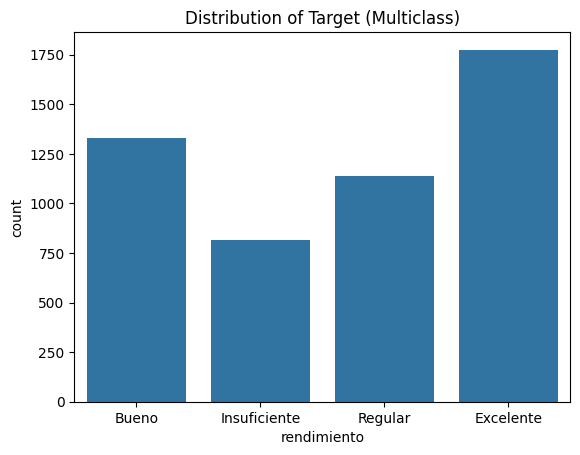

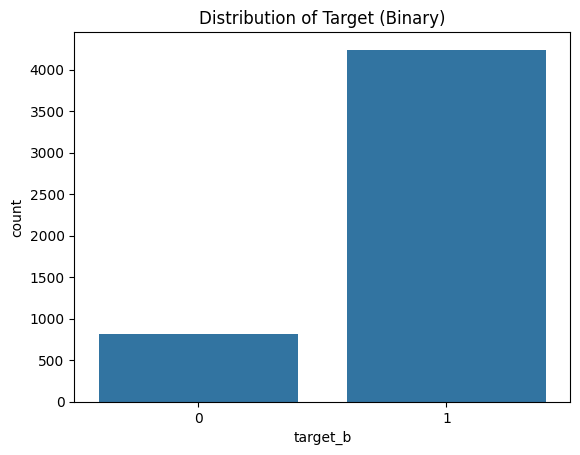

In [619]:
Ctraining = pd.concat([train, val], axis=0).reset_index(drop=True)

sns.countplot(data=Ctraining, x="rendimiento")
plt.title("Distribution of Target (Multiclass)")
plt.show()

Ctraining["target_b"] = (Ctraining["rendimiento"] != "Insuficiente").astype(int)

sns.countplot(data=Ctraining, x="target_b")
plt.title("Distribution of Target (Binary)")
plt.show()


La distribución de la variable objetivo se encuentra balanceada, con una alta concentración de observaciones en la categoría "Excelente" y una disminución progresiva en la frecuencia a medida que baja el nivel de rendimiento.

En su versión binaria, hay un desbalance evidente, ya que la cantidad de alumnos aprobados supera ampliamente a la de desaprobados (aproximadamente 4000 frente a 800).

Las variables categóricas serán transformadas a representaciones numéricas para poder ser utilizadas por los modelos de aprendizaje automático.

- rendimiento: se aplicará un mapeo a valores numéricos entre 0 y 3, respetando el orden natural de las categorías (de menor a mayor desempeño). Esto permite preservar la información ordinal de la variable.

- escuela: se utilizará codificación one-hot, ya que se trata de una variable categórica nominal sin un orden inherente. Esta transformación evita introducir relaciones artificiales entre las categorías. La transformación se hará luego del análisis para la simplicidad de los gráficos.

- semestre: se transformó a una variable numérica mediante una función que combina el año y el semestre (año * 2 + semestre), con el objetivo de preservar su estructura temporal y permitir al modelo capturar posibles tendencias en el tiempo.

array([[<Axes: title={'center': 'horas_estudio'}>,
        <Axes: title={'center': 'asistencia'}>,
        <Axes: title={'center': 'nota_previa'}>],
       [<Axes: title={'center': 'horas_sueno'}>,
        <Axes: title={'center': 'participacion'}>,
        <Axes: title={'center': 'horas_extracurricular'}>],
       [<Axes: title={'center': 'acceso_internet'}>,
        <Axes: title={'center': 'distancia_escuela_km'}>,
        <Axes: title={'center': 'nivel_socioeconomico'}>],
       [<Axes: title={'center': 'tamano_clase'}>,
        <Axes: title={'center': 'semestre'}>,
        <Axes: title={'center': 'rendimiento'}>]], dtype=object)

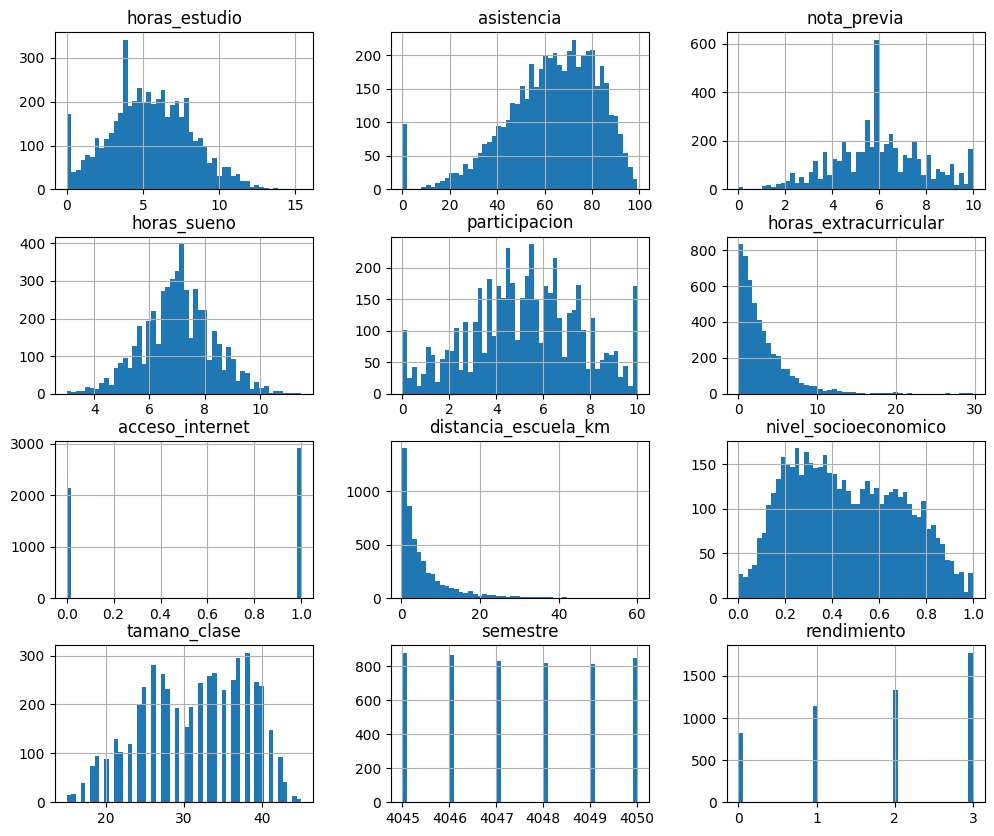

In [620]:
notes = {
    "Insuficiente": 0,
    "Regular": 1,
    "Bueno": 2,
    "Excelente": 3
}

for data in [train, val, data_test]:
    data["semestre"] = data["semestre"].apply(semestre_to_int)
    data["rendimiento"] = data["rendimiento"].map(notes)

data_total = pd.concat([train, val], axis=0).reset_index(drop=True)
data_total.hist(figsize=(12, 10), bins=50)

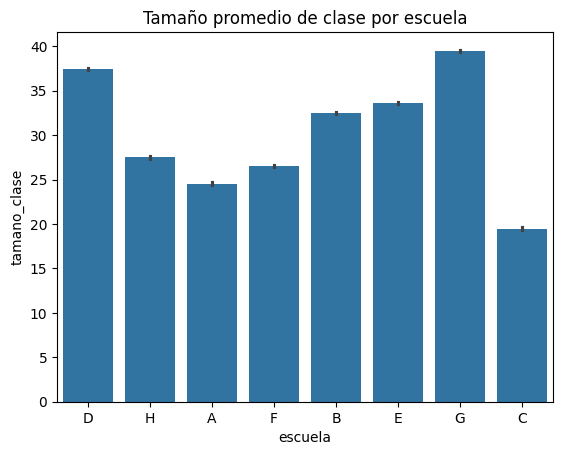

In [621]:
sns.barplot(data=data_total, x="escuela", y="tamano_clase")
plt.title("Tamaño promedio de clase por escuela")
plt.show()

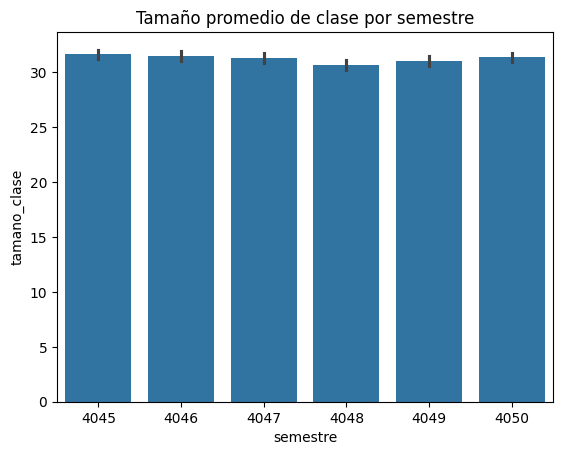

In [622]:
sns.barplot(data=data_total, x="semestre", y="tamano_clase")
plt.title("Tamaño promedio de clase por semestre")
plt.show()

El análisis de las distribuciones muestra que algunas variables como horas_estudio, horas_sueno y asistencia presentan formas aproximadamente normales, concentrándose en valores intermedios. En contraste, variables como horas_extracurricular y distancia_escuela_km presentan un fuerte sesgo hacia la derecha, con presencia de valores extremos. Otras variables, como tamano_clase, presentan distribuciones discretas debido a la naturaleza de los datos. Asimismo, acceso_internet es una variable binaria, mientras que nivel_socioeconomico y participación se encuentran acotadas. La variable tamano_clase no varía casi con respecto a los semestres, no hay concentraciones significativas en períodos específicos. Por otro lado, las escuelas si tienen una variación, con clases mas pequeñas en instituciones como A y C y considerablemente más grandes en otras como D y G.

In [623]:
# sns.pairplot(data_total, hue="escuela")

Al analizar las variables segmentadas por escuela, se observa que, en general, las distribuciones dentro de cada grupo presentan formas aproximadamente normales, concentrándose en valores intermedios.
Por otro lado, no se identifican correlaciones fuertes entre la mayoría de las variables. Sin embargo, se destaca una relación negativa entre nivel_socioeconomico y tamano_clase, lo que sugiere que, a mayor nivel socioeconómico, el tamaño de la clase tiende a ser menor. Esto explica lo que se había previamente mencionado sobre las escuelas y el tamaño de clase, dando a entender que las de mayor nivel socioeconómico suelen tener clases mas pequeñas.

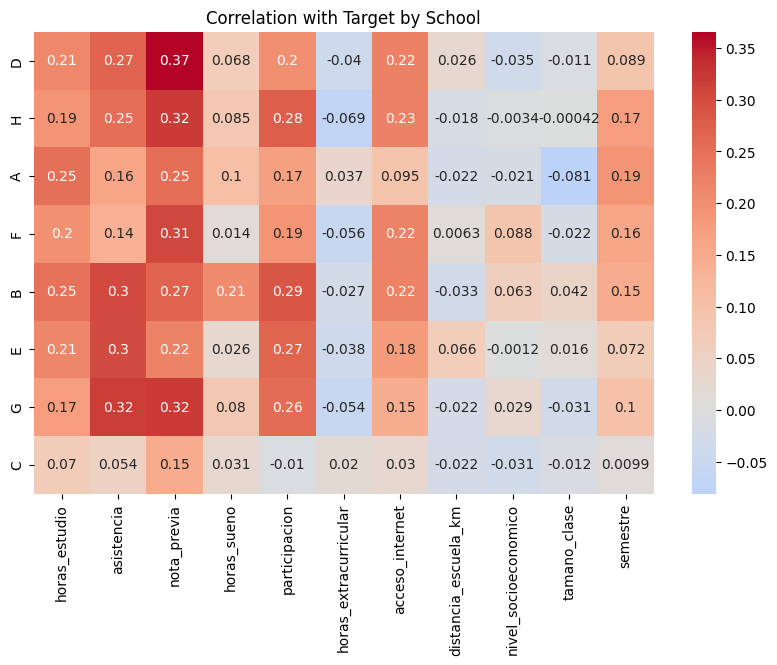

In [624]:
corr_list = []

for escuela in data_total["escuela"].unique():
    
    df_esc = data_total[data_total["escuela"] == escuela]
    
    corr = df_esc.corr(numeric_only=True)["rendimiento"]
    
    corr.name = escuela 
    
    corr_list.append(corr)

corr_by_school = pd.DataFrame(corr_list)
corr_by_school = corr_by_school.drop(columns=["rendimiento"], errors="ignore")

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_by_school,
    annot=True,
    cmap="coolwarm",
    center=0
) 

plt.title("Correlation with Target by School")
plt.show()

No se observan diferencias significativas en la correlación entre las variables y la variable objetivo al segmentar por escuela. En general, las correlaciones son relativamente bajas y consistentes entre instituciones, lo que sugiere que la relación entre las variables explicativas y el rendimiento no varía sustancialmente según la escuela.

Resulta llamativo que variables intuitivamente relevantes, como horas_estudio, presenten correlaciones bajas con la variable objetivo. Esto podría indicar que la relación no es lineal, que existen otros factores que influyen con mayor peso en el rendimiento, o que el efecto de estas variables se manifiesta en combinación con otras.

Por otro lado, nota_previa es la variable que presenta la mayor correlación con el rendimiento en todas las escuelas, lo cual es consistente con lo esperado, ya que el desempeño pasado suele ser un buen predictor del desempeño futuro.

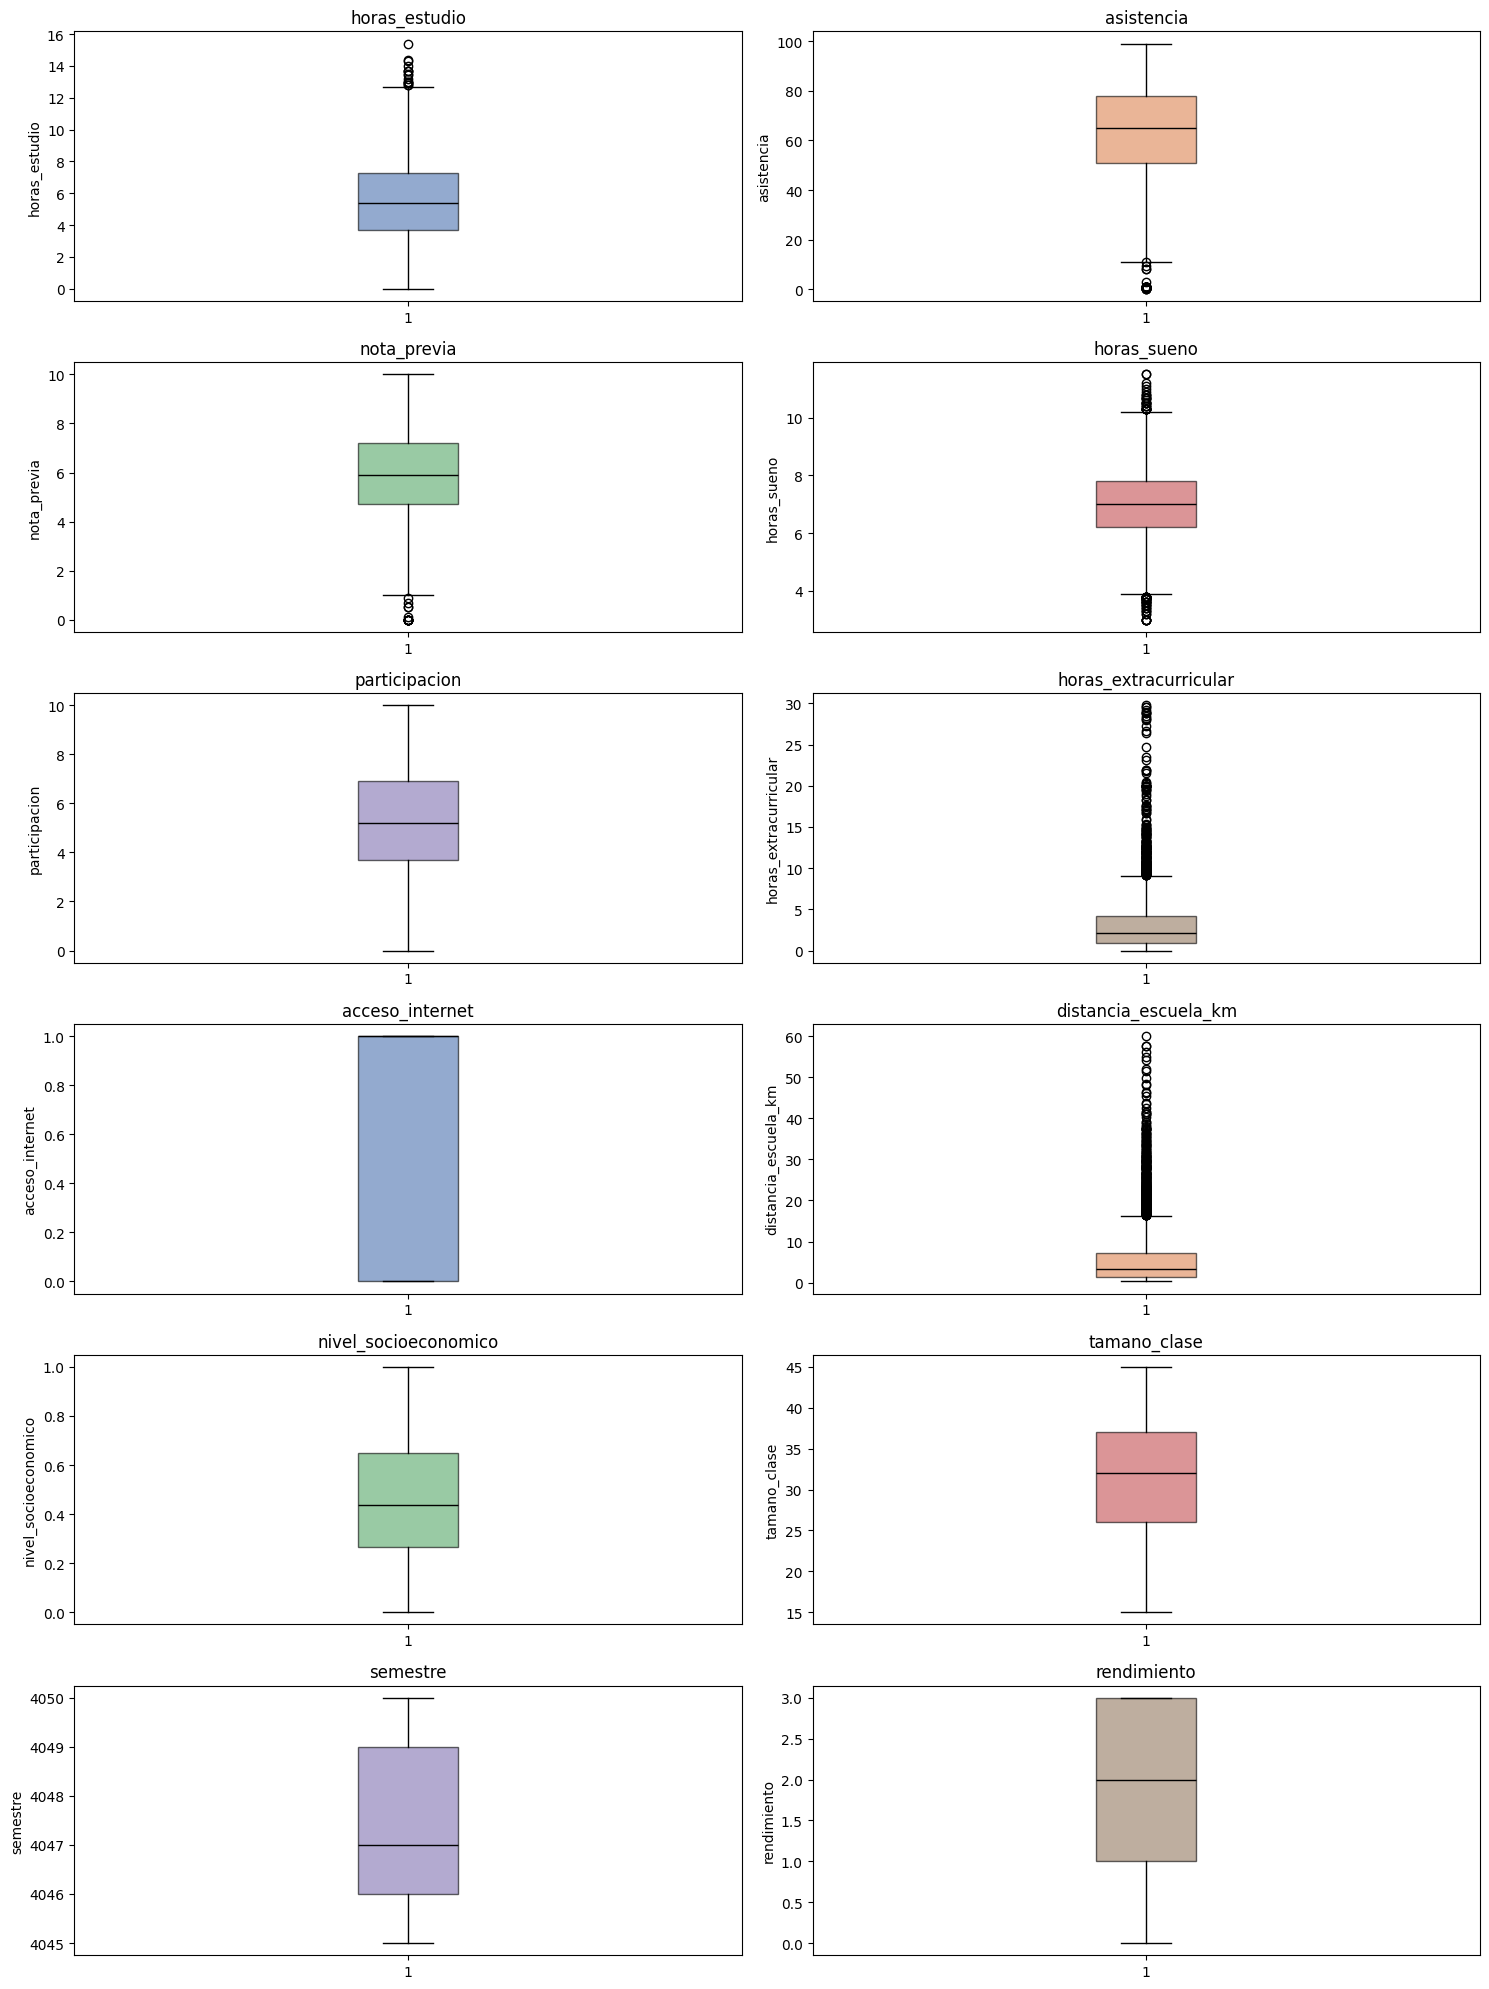

In [625]:
features_analysis = data_total.select_dtypes(include=["float64", "int64"]).columns

n_features = len(features_analysis)
n_cols = 2
n_rows = (n_features + 1) // n_cols

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.ravel()

for i, feature in enumerate(features_analysis):
    
    bp = axes[i].boxplot(data_total[feature], patch_artist=True)
    
    bp["boxes"][0].set_facecolor(colors[i % len(colors)])
    bp["boxes"][0].set_alpha(0.6)
    bp["medians"][0].set_color("black")
    
    axes[i].set_title(feature)
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

Se identificaron valores atípicos en variables como distancia_escuela_km, horas_extracurricular, horas_estudio y horas_sueno. Sin embargo, estos valores no corresponden a errores en los datos, sino a observaciones poco frecuentes pero plausibles dentro del contexto del problema (por ejemplo, estudiantes que viven lejos o dedican muchas horas a actividades). Por este motivo, no se optará por eliminar dichos valores, ya que su exclusión podría implicar una pérdida de información relevante para el modelo. En su lugar, para aquellas variables que presentan distribuciones fuertemente sesgadas, como distancia_escuela_km y horas_extracurricular, se aplicará una transformación logarítmica. Esta permite reducir el impacto de los valores extremos, comprimiendo las colas de la distribución y generando una forma más simétrica, lo cual resulta beneficioso para el desempeño de modelos lineales.

In [626]:
for data in [train, val, data_test]:
    data["distancia_escuela_km"] = np.log1p(data["distancia_escuela_km"])
    data["horas_extracurricular"] = np.log1p(data["horas_extracurricular"])

In [627]:
train_print, val_print, data_test_print = one_hot_encoder_school(train.copy(), val.copy(), data_test.copy())
data_total = pd.concat([train_print, val_print], axis=0).reset_index(drop=True)

data_total.to_csv("../data/processed/rendimiento_estudiantes_dev_processed.csv", index=False)
data_test_print.to_csv("../data/processed/rendimiento_estudiantes_test_processed.csv", index=False)

In [628]:
# features = train.select_dtypes(include=["float64", "int64"]).columns

# train, statistics = normalize_train(train, features)
# val = normalize_val_test(val, features, statistics)
# data_test = normalize_val_test(data_test, features, statistics)

# Clasificación Binaria y Estrategias de Splitting


In [629]:
data_train["rendimiento"] = data_train.copy()["rendimiento"].map(notes)
data_train["target_b"] = (data_train.copy()["rendimiento"] != 0).astype(int)
data_train["semestre"] = data_train.copy()["semestre"].apply(semestre_to_int)

features = [col for col in data_train.select_dtypes(include=["float64", "int64"]).columns 
            if col not in ["target_b"]]

train_school, val_school = group_split_by_school(data_train, num_schools_val=2, random_state=42)
train_random, val_random = random_split(data_train, test_size=0.2, random_state=42)
train_temporal, val_temporal = temporal_split(data_train)

results = []

for train_set, val_set, name in zip(
    [train_school, train_random, train_temporal],
    [val_school, val_random, val_temporal],
    ["Group by School", "Random Split", "Temporal Split"]
):
    print(f"\n===== {name} =====")

    train_set, val_set = nulls_nota_previa(train_set, val_set)
    train_set, val_set = adjust_nulls(train_set, val_set)

    train_set, statistics = normalize_train(train_set, features)
    val_set = normalize_val_test(val_set, features, statistics)

    train_set, val_set = one_hot_encoder2(train_set.copy(), val_set.copy())

    X_train = train_set.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_train = train_set["target_b"].values
    
    X_val = val_set.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_val = val_set["target_b"].values

    print(f"X Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    print(f"Y Training samples: {len(y_train)}, Validation samples: {len(y_val)}")

    model = LogisticRegression(X_train, y_train, L2=0.1)
    model.fit(L2=True)
    
    y_pred = model.prediction(X_val)
    y_prob = model.probability(X_val)
    
    print_confusion_matrix(y_val, y_pred)
    print_metrics(y_val, y_pred, title=f"{name} - Metrics")

    results.append({"name": name, "y_true": y_val, "y_prob": y_prob})


===== Group by School =====
X Training samples: 3898, Validation samples: 1160
Y Training samples: 3898, Validation samples: 1160
Reached maximum iterations without convergence.
Final Loss: 0.3785
Weights: [ 0.17026863  0.24929832  0.26908257  0.06678941  0.20826931 -0.02874634
  0.13522891 -0.07909083  0.16997034 -0.20907295  0.06457828  0.09646396
  0.13870309  0.05430771  0.02648079  0.10575615 -0.00455645]
Bias: 1.2751497504700025
Confusion Matrix:
TP: 1098 | FP: 52
FN: 5 | TN: 5

Group by School - Metrics:
Accuracy: 0.9509
Precision: 0.9548
Recall: 0.9955
F1 Score: 0.9747

===== Random Split =====
X Training samples: 4046, Validation samples: 1012
Y Training samples: 4046, Validation samples: 1012
Reached maximum iterations without convergence.
Final Loss: 0.3527
Weights: [ 0.15594512  0.23321608  0.24094545  0.03793377  0.19765187 -0.01937715
  0.11877204 -0.03884996  0.16139279 -0.20824127  0.05955361  0.07296795
  0.09950533  0.04130276  0.00151318  0.1092035   0.07890098 -0.0

Si bien se esperaría una caída significativa en el desempeño al utilizar estrategias como group split o temporal split, los resultados muestran métricas elevadas en todos los casos. Esto se debe principalmente al fuerte desbalance de la variable objetivo, donde la clase positiva es ampliamente mayoritaria. En este contexto, el modelo tiende a predecir la clase dominante, logrando altos valores de accuracy, precision, recall y F1-score.

Sin embargo, al analizar la matriz de confusión, se observa que el modelo presenta un bajo desempeño en la identificación de la clase minoritaria, evidenciado por una baja cantidad de verdaderos negativos y una alta proporción de falsos positivos. Esto sugiere que, si bien las métricas globales son altas, el modelo no está capturando adecuadamente la estructura de la clase minoritaria.

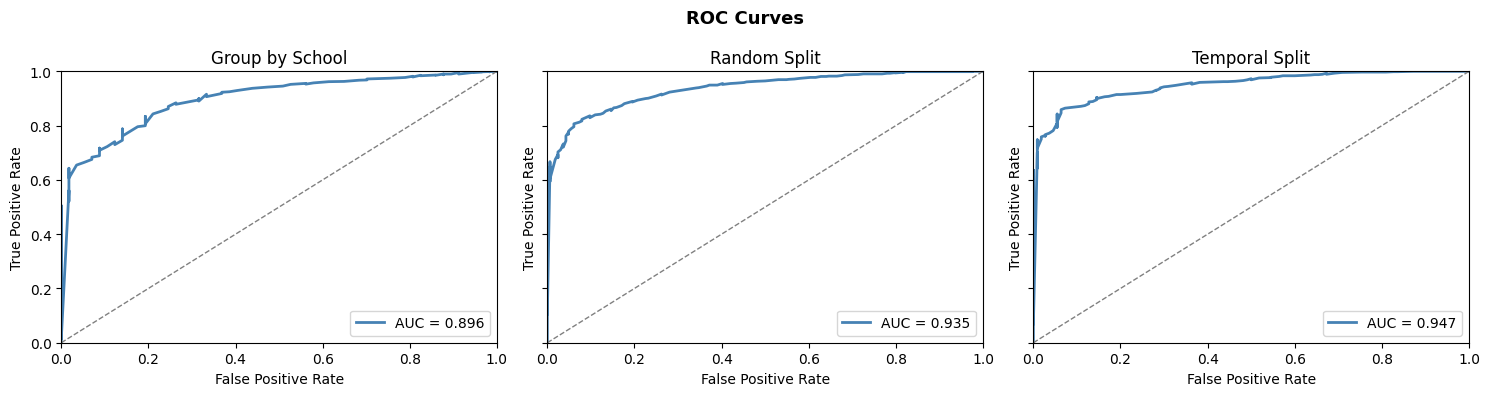

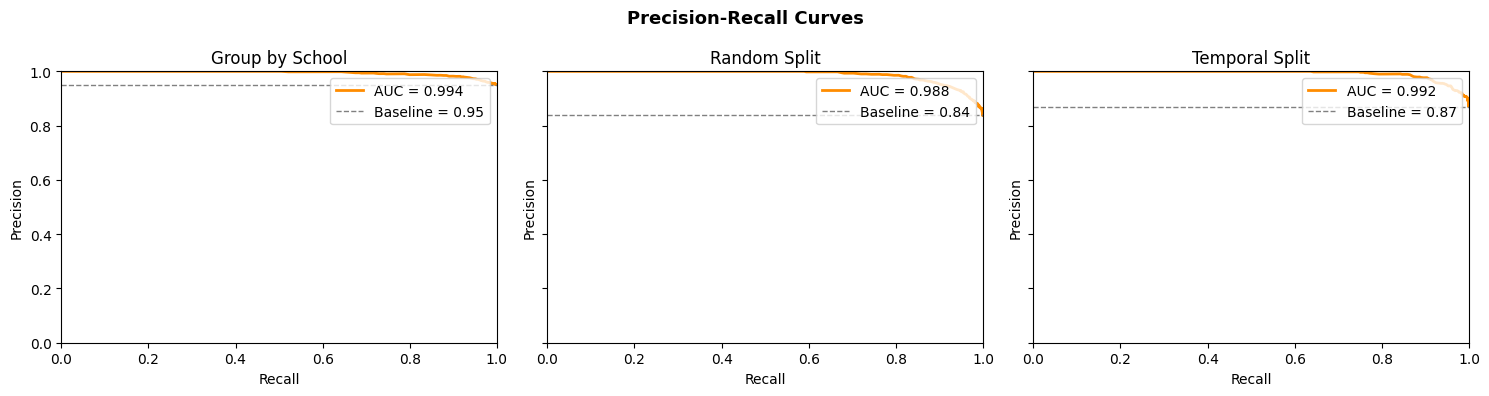

In [630]:
plot_roc_curves(results)
plot_pr_curves(results)

En el gráfico ROC las tres curvas se ubican muy por encima de la diagonal, lo que indica que el modelo distingue bien entre clases en todos los casos. El AUC más bajo corresponde al Group Split (0.896), lo cual es esperable: al entrenar sin datos de 2 escuelas y validar sobre ellas, el modelo enfrenta distribuciones no vistas, lo que dificulta la generalización. El Random Split y el Temporal Split obtienen AUCs similares y más altos (0.935 y 0.947), ya que en ambos casos todas las escuelas están representadas en entrenamiento. Por esta razón se concluye que el model no generaliza bien por problemas de calibración del threshold.

Los AUC-PR son muy altos en los tres casos (>0.98), pero esto debe interpretarse con cuidado dado el fuerte desbalance de clases — la baseline (proporción de positivos) es de 0.95, 0.84 y 0.87 según el split. Con tanta clase positiva, un modelo que predice casi siempre 1 ya obtiene precision alta naturalmente. Por eso la curva PR no cae demasiado incluso en el Group Split. La métrica más informativa en este contexto es el comportamiento en los extremos de recall bajo, donde se puede observar que el modelo sí logra precision cercana a 1 cuando es más selectivo, lo que sugiere que las features aportan información real más allá del sesgo de clase.